# spectra - a linear-algebra-first deep learning framework

**Raya Sergieva**

This notebook is the research report accompanying the
[spectra](https://github.com/RayaSergieva/ml-research-pipeline) framework, a
deep learning library written from scratch in NumPy. Everything the library
does is derived here from linear algebra and matrix calculus before it is
used, and the trained networks are then taken apart with the library's own
spectral instruments.

## 1. Problem formulation

Deep learning frameworks are usually consumed as black boxes. The premise of
this project is that every component of a working framework - automatic
differentiation, initialization, optimization, the training dynamics
themselves - is a small number of linear-algebraic ideas, and that building
the whole stack from those ideas produces both a working artifact and real
understanding.

The project therefore has two intertwined goals.

**The framework.** A NumPy-only library with a `Tensor` type, reverse-mode
automatic differentiation, neural network modules, optimizers, and a test
suite whose core is finite-difference gradient checking.

**The research question.** How does a neural network reorganize itself
*spectrally* during training? Concretely, how do the singular value spectra
of the weight matrices evolve as a network learns, and can that be exploited -
for example, through initialization schemes that set the spectrum
deliberately?

Scope for this report - a multilayer perceptron trained on MNIST, tracked
with a spectral analyzer, plus the mathematical development of every
component used along the way. The framework itself supports more
(the repository road map documents the ongoing extensions).

### Why this matters

Automatic differentiation is the single algorithm underlying all of modern
deep learning, yet it is just the chain rule organized around a graph.
Initialization theory decides whether a deep network trains at all, and it is
a variance propagation argument. The spectrum of a weight matrix is a
complete, orientation-free description of what a layer does to its input
space. These are exactly the topics a linear algebra course equips one to
treat rigorously, and this project does so end to end.

## 2. Tensors and the anatomy of a differentiable program

### 2.1 The Tensor

A tensor here is simply an $n$-dimensional array of real numbers together
with bookkeeping for differentiation. Formally, a tensor of shape
$(d_1, \dots, d_k)$ is an element of $\mathbb{R}^{d_1 \times \cdots \times d_k}$.
The framework wraps `numpy.ndarray` and adds three fields - `requires_grad`
marking the tensor as a differentiation variable, `grad` holding the
accumulated gradient, and an internal reference to the operation that
produced it, which is how the computational graph is stored.

In [1]:
import numpy as np

from spectra import Tensor

x = Tensor([[1.0, 2.0], [3.0, 4.0]], requires_grad=True)
x

Tensor([[1., 2.],
 [3., 4.]], dtype=float64, requires_grad=True)

### 2.2 Functions as graphs

A numerical program is a composition of primitive operations. Writing
$L = f_3(f_2(f_1(x)))$, each intermediate value is a node and each primitive
an edge, giving a directed acyclic graph. In spectra the graph is built
implicitly - evaluating an expression records, on each result, which
operation produced it and from which inputs.

In [2]:
a = Tensor([2.0], requires_grad=True)
b = Tensor([3.0], requires_grad=True)
c = a * b + a  # two primitive nodes, recorded automatically
c._ctx, [p.data for p in c._ctx.parents]

(<spectra.ops.Add at 0x1e2c0fdc680>, [array([6.]), array([2.])])

## 3. Matrix calculus and reverse-mode differentiation

### 3.1 Derivatives of vector- and matrix-valued maps

For $f : \mathbb{R}^n \to \mathbb{R}^m$, the derivative at $x$ is the Jacobian

$$
J_f(x) \in \mathbb{R}^{m \times n}, \qquad
[J_f(x)]_{ij} = \frac{\partial f_i}{\partial x_j}(x),
$$

the unique linear map satisfying $f(x + h) = f(x) + J_f(x)\,h + o(\lVert h\rVert)$.
For a composition $L = g(f(x))$ with $g : \mathbb{R}^m \to \mathbb{R}$ the chain
rule reads

$$
\nabla_x L \;=\; J_f(x)^{\top} \, \nabla_{f(x)} g .
$$

This single line is the entire backward pass. Every operation must be able to
answer one question - given the gradient of the loss with respect to my
output, what is the gradient with respect to each of my inputs? That map,
$v \mapsto J^{\top} v$, is the **vector-Jacobian product** (VJP). Note what is
*not* required - the Jacobian itself is never materialized. For a layer with
input and output dimension $10^3$, the Jacobian has $10^6$ entries per sample,
while the VJP is computed with a handful of matrix products.

### 3.2 Why reverse mode

Consider a scalar loss $L : \mathbb{R}^n \to \mathbb{R}$ built from $k$
primitives. Two evaluation orders of the chain rule exist.

*Forward mode* propagates $\partial(\cdot)/\partial x_j$ alongside the
computation, one input direction at a time - $n$ passes for a full gradient.

*Reverse mode* propagates $\partial L/\partial(\cdot)$ backward from the
output, all inputs at once - one pass, at a cost proportional to the forward
evaluation.

Training a network means $n$ in the millions (every weight) and a scalar $L$.
Reverse mode wins by a factor of $n$. This asymmetry, not any deep principle,
is why backpropagation is *the* algorithm of deep learning.

### 3.3 The VJP rules used by spectra

Each rule below is the transpose-Jacobian action, derived once and tested by
finite differences in `tests/test_autograd.py`. Writing $G$ for the incoming
gradient $\partial L / \partial(\text{output})$,

| operation | forward | VJP w.r.t. inputs |
|---|---|---|
| add | $C = A + B$ | $G$, $\;G$ |
| multiply | $C = A \odot B$ | $G \odot B$, $\;G \odot A$ |
| matmul | $C = AB$ | $G B^{\top}$, $\;A^{\top} G$ |
| sum | $s = \sum_i a_i$ | broadcast of $G$ |
| ReLU | $c_i = \max(a_i, 0)$ | $G \odot \mathbf{1}[a > 0]$ |
| exp | $c_i = e^{a_i}$ | $G \odot e^{a}$ |
| log | $c_i = \ln a_i$ | $G \oslash a$ |

The matmul rule is worth deriving explicitly since it anchors everything
else. With $L$ scalar and $C = AB$,

$$
\frac{\partial L}{\partial A_{ij}}
= \sum_{k} \frac{\partial L}{\partial C_{ik}} \frac{\partial C_{ik}}{\partial A_{ij}}
= \sum_{k} G_{ik} B_{jk}
= (G B^{\top})_{ij},
$$

and symmetrically $\partial L/\partial B = A^{\top} G$. The derivative of a
matrix product is again a pair of matrix products, which is what makes the
backward pass as cheap as the forward pass.

### 3.4 Broadcasting and its adjoint

NumPy silently *broadcasts* operands of unequal shape, replicating a smaller
array along new or size-one axes. Broadcasting is a linear map (replication),
so the chain rule needs its adjoint, and the adjoint of replication is
summation over the replicated axes. Every elementwise VJP in spectra is
therefore followed by an `_unbroadcast` step summing the gradient back down
to the operand's shape. Getting this wrong is the classic autograd bug, and
it is exactly the kind of error finite-difference checking catches.

### 3.5 Fan-out and gradient accumulation

When one tensor feeds several operations, the multivariate chain rule sums
the contributions,

$$
\frac{\partial L}{\partial x}
= \sum_{p \,\in\, \text{paths}} \frac{\partial L}{\partial u_p}\frac{\partial u_p}{\partial x},
$$

implemented as `parent.grad += g` while the graph is walked in reverse
topological order. The walk itself is an iterative depth-first
post-ordering, so graph depth is limited by memory rather than the Python
recursion limit.

In [3]:
# The engine at work - d/da of (a*b + a) is b + 1, and d/db is a.
a = Tensor([2.0], requires_grad=True)
b = Tensor([3.0], requires_grad=True)
(a * b + a).sum().backward()
a.grad, b.grad

(array([4.]), array([2.]))

### 3.6 Validating the engine - gradient checking

An analytic gradient is trusted only against an independent oracle. The
central difference

$$
\frac{\partial L}{\partial x_i} \;\approx\;
\frac{L(x + \varepsilon e_i) - L(x - \varepsilon e_i)}{2\varepsilon}
$$

has error $O(\varepsilon^2)$ by Taylor expansion, since the even-order terms
cancel. With $\varepsilon = 10^{-6}$ and float64 arithmetic the truncation
and round-off errors are both far below the comparison tolerance, so
disagreement means a wrong VJP, not noise. The test suite runs this check on
every operation and on composite expressions, including a full
two-layer-network loss differentiated with respect to a weight matrix.

In [4]:
def numerical_grad(f, x, eps=1e-6):
    g = np.zeros_like(x)
    it = np.nditer(x, flags=["multi_index"])
    while not it.finished:
        i = it.multi_index
        orig = x[i]
        x[i] = orig + eps
        plus = f(x)
        x[i] = orig - eps
        minus = f(x)
        x[i] = orig
        g[i] = (plus - minus) / (2 * eps)
        it.iternext()
    return g


rng = np.random.default_rng(0)
W_data = rng.standard_normal((4, 3))
x_data = rng.standard_normal((8, 4))

# analytic gradient via spectra
W = Tensor(W_data.copy(), requires_grad=True)
((Tensor(x_data) @ W).relu()).mean().backward()


# numerical gradient via central differences
def loss(w):
    return float(((Tensor(x_data) @ Tensor(w)).relu()).mean().data)


num = numerical_grad(loss, W_data.copy())

print("max abs difference:", np.abs(W.grad - num).max())
assert np.allclose(W.grad, num, atol=1e-8)

max abs difference: 1.647616765243498e-11


## 4. Initialization as spectral design

### 4.1 The variance propagation argument

Consider one linear layer $y = W x$ with $W \in \mathbb{R}^{n_\text{out} \times n_\text{in}}$
(orientation chosen for this derivation; the code stores the transpose),
entries $W_{ij}$ i.i.d. with mean $0$ and variance $\sigma^2$, independent of
$x$, whose entries have mean $0$ and variance $v$. Then

$$
\operatorname{Var}(y_i)
= \operatorname{Var}\Big(\sum_{j=1}^{n_\text{in}} W_{ij} x_j\Big)
= \sum_{j=1}^{n_\text{in}} \operatorname{Var}(W_{ij} x_j)
= n_\text{in}\, \sigma^2 v .
$$

Stacking $d$ such layers multiplies the input variance by
$(n_\text{in}\sigma^2)^d$. Unless $n_\text{in}\sigma^2 = 1$ exactly, the
activations grow or shrink *geometrically* with depth, and the same
computation applied to the backward pass shows gradients scale by
$(n_\text{out}\sigma^2)$ per layer. This is the entire vanishing/exploding
problem for feedforward nets, and it dictates the schemes the framework
implements.

**Xavier / Glorot.** Balancing both directions at once is impossible when
$n_\text{in} \neq n_\text{out}$, so Glorot & Bengio (2010) take the harmonic
compromise
$\sigma^2 = 2 / (n_\text{in} + n_\text{out})$.

**He.** A ReLU zeroes every negative input. For a symmetric zero-mean
pre-activation $z$, $\mathbb{E}[\max(z,0)^2] = \tfrac12 \mathbb{E}[z^2]$, so
each ReLU halves the propagated second moment. He et al. (2015) compensate by
doubling the weight variance, $\sigma^2 = 2 / n_\text{in}$.

The experiment below propagates data through a 30-layer random ReLU network
and measures activation standard deviation per layer, for a naive
$\sigma = 0.05$, for $\sigma^2 = 1/n$ (Xavier-like, ignoring ReLU), and for
He initialization.

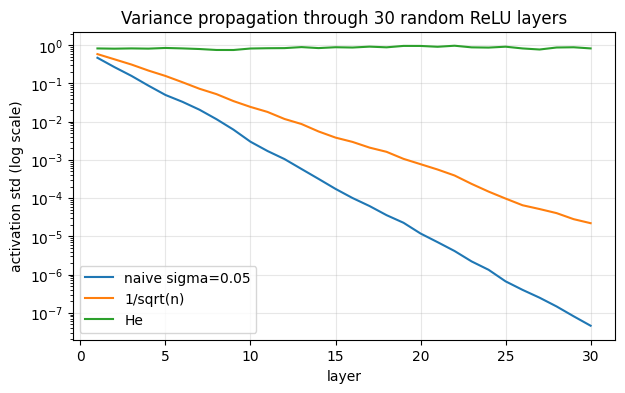

In [5]:
import matplotlib.pyplot as plt

from spectra import Tensor, init

rng = np.random.default_rng(0)
n, depth = 256, 30
x0 = rng.standard_normal((512, n))

schemes = {
    "naive sigma=0.05": lambda: rng.standard_normal((n, n)) * 0.05,
    "1/sqrt(n)": lambda: rng.standard_normal((n, n)) / np.sqrt(n),
    "He": lambda: init.he_normal((n, n), rng),
}

plt.figure(figsize=(7, 4))
for label, make in schemes.items():
    h = Tensor(x0.copy())
    stds = []
    for _ in range(depth):
        h = (h @ Tensor(make())).relu()
        stds.append(float(h.data.std()))
    plt.semilogy(range(1, depth + 1), stds, label=label)
plt.xlabel("layer")
plt.ylabel("activation std (log scale)")
plt.title("Variance propagation through 30 random ReLU layers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The naive scheme collapses to numerical zero within a dozen layers and the
ReLU-blind scheme decays geometrically at rate $(1/2)^{d/2}$, exactly the
halving the derivation predicts, while He initialization holds the activation
scale flat across all 30 layers. A network whose signal has vanished cannot
train, so this single plot is the practical content of initialization theory.

### 4.2 The spectral view

Initialization also sets the *spectrum* a layer starts from. For a large
random matrix with i.i.d. entries of variance $\sigma^2 = 1/n$, the
Marchenko-Pastur law describes the limiting singular value distribution - a
bulk supported on $[0, 2]$ for square matrices, with no outliers. Training
will deform this spectrum, and measuring that deformation is the purpose of
the spectral tracker used in the experiment section.

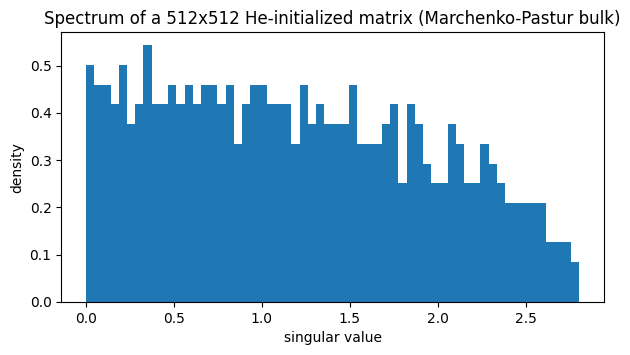

In [6]:
w = init.he_normal((512, 512), np.random.default_rng(1))
s = np.linalg.svd(w, compute_uv=False)

plt.figure(figsize=(7, 3.5))
plt.hist(s, bins=60, density=True)
plt.xlabel("singular value")
plt.ylabel("density")
plt.title("Spectrum of a 512x512 He-initialized matrix (Marchenko-Pastur bulk)")
plt.show()

## 5. Optimization

### 5.1 Gradient descent and conditioning

For the model quadratic $f(\theta) = \tfrac12 \theta^{\top} A \theta$ with
$A \succ 0$, gradient descent $\theta_{t+1} = \theta_t - \eta A \theta_t$
acts on each eigenvector direction of $A$ independently, scaling the
coefficient along an eigenvalue-$\lambda$ direction by $(1 - \eta\lambda)$
per step. Convergence requires $|1 - \eta\lambda| < 1$ for every eigenvalue,
so the largest eigenvalue caps the step size at $\eta < 2/\lambda_{\max}$,
while the *slowest* direction contracts at $(1 - \eta\lambda_{\min})$. With
the optimal step size the error contracts per step by a factor

$$
\rho = \frac{\kappa - 1}{\kappa + 1}, \qquad \kappa = \frac{\lambda_{\max}}{\lambda_{\min}},
$$

so the condition number $\kappa$ alone governs the speed of gradient descent
on quadratics. This is the same condition number the spectral tracker
records for every weight matrix - conditioning is where optimization and
spectral structure meet.

### 5.2 Momentum and Adam

Classical momentum $v_{t+1} = m v_t + g_t$, $\theta_{t+1} = \theta_t - \eta v_{t+1}$
turns the per-direction recursion into a damped oscillator; with tuned
parameters the contraction factor improves to
$(\sqrt{\kappa} - 1)/(\sqrt{\kappa} + 1)$, a quadratic speedup in $\kappa$.
Adam (Kingma & Ba, 2015) instead keeps exponential moving averages of the
gradient and its square, corrects both for initialization bias (the averages
start at zero, so early estimates are scaled up by $1/(1-\beta^t)$), and
divides the step per coordinate by the root of the second moment,
$\theta_{t+1} = \theta_t - \eta\, \hat m_t / (\sqrt{\hat v_t} + \epsilon)$ -
an approximately scale-free step size per coordinate.

The race below runs the framework's own SGD, SGD with momentum, and Adam on
an ill-conditioned quadratic with $\kappa = 100$.

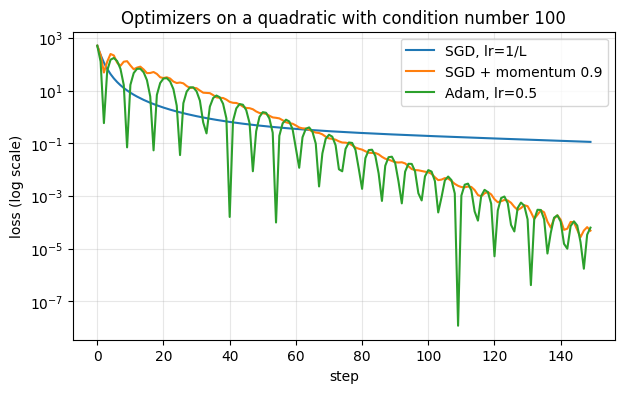

In [7]:
from spectra.optim import SGD, Adam

eigs = np.linspace(1.0, 100.0, 20)  # kappa = 100
A = np.diag(eigs)


def run(make_opt, steps=150):
    theta = Tensor(np.ones(20), requires_grad=True)
    opt = make_opt([theta])
    losses = []
    for _ in range(steps):
        opt.zero_grad()
        loss = (theta * Tensor(A @ theta.data)).sum() * 0.5
        loss.backward()
        opt.step()
        losses.append(float(loss.data))
    return losses


curves = {
    "SGD, lr=1/L": run(lambda p: SGD(p, lr=1.0 / eigs.max())),
    "SGD + momentum 0.9": run(lambda p: SGD(p, lr=1.0 / eigs.max(), momentum=0.9)),
    "Adam, lr=0.5": run(lambda p: Adam(p, lr=0.5)),
}

plt.figure(figsize=(7, 4))
for label, losses in curves.items():
    plt.semilogy(losses, label=label)
plt.xlabel("step")
plt.ylabel("loss (log scale)")
plt.title("Optimizers on a quadratic with condition number 100")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Plain gradient descent crawls at the $\rho = 99/101$ rate the theory
predicts, momentum accelerates it dramatically, and Adam's per-coordinate
scaling effectively rescales the problem to $\kappa \approx 1$. On real
losses the picture is less clean, but the mechanism seen here - conditioning
controls speed, momentum and adaptivity fight conditioning - transfers.

### 5.3 The classification loss

Training a classifier minimizes the cross-entropy between the softmax of the
logits $z \in \mathbb{R}^C$ and the label $y$,

$$
L(z, y) = -\log \operatorname{softmax}(z)_y
        = -z_y + \log \sum_{c=1}^{C} e^{z_c}.
$$

Two facts derived in the loss module's documentation and verified in its
tests. Numerically, $\log\sum e^{z_c}$ must be evaluated as
$m + \log\sum e^{z_c - m}$ with $m = \max_c z_c$, otherwise $e^{z}$ overflows
float64 already at $z \approx 710$. Analytically, the gradient collapses to

$$
\frac{\partial L}{\partial z_c} = \operatorname{softmax}(z)_c - \mathbf{1}[c = y],
$$

the predicted distribution minus the target one-hot - the error signal the
network back-propagates.

## 6. The experiment - an MLP on MNIST, watched through its spectra

The script `experiments/train_mlp_mnist.py` trains a 784-256-128-10 ReLU
network with Adam (lr $10^{-3}$, batch 128, 5 epochs, seed 0) on MNIST,
logging every measurement to `runs/mlp_mnist.jsonl` and capturing the full
singular value spectrum of all three weight matrices every 50 optimizer
steps into `runs/mlp_mnist_spectra.npz`. This section analyzes that run.
Reproducing it end to end is one command,

```
uv run python experiments/train_mlp_mnist.py
```

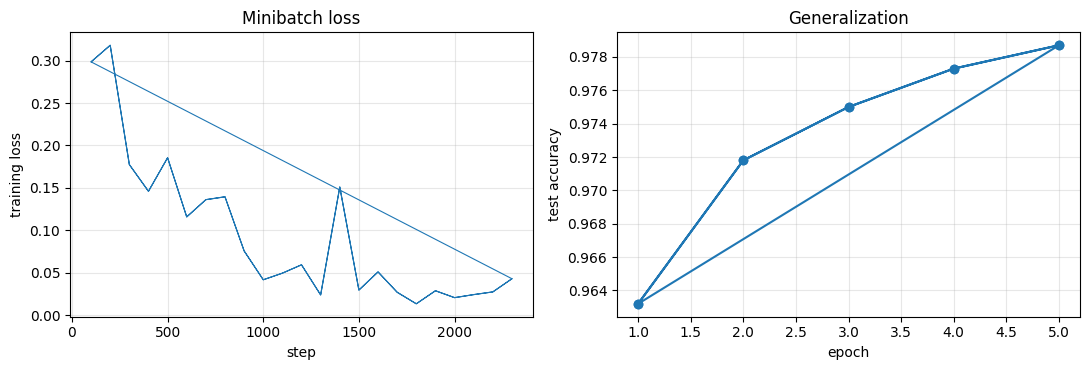

final test accuracy: 0.9787


In [8]:
from spectra.utils import read_run

records = read_run("../runs/mlp_mnist.jsonl")
train = [r for r in records if r.get("event") == "train"]
epochs = [r for r in records if r.get("event") == "epoch"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot([r["step"] for r in train], [r["loss"] for r in train], lw=0.8)
axes[0].set_xlabel("step")
axes[0].set_ylabel("training loss")
axes[0].set_title("Minibatch loss")
axes[0].grid(True, alpha=0.3)
axes[1].plot([r["epoch"] for r in epochs], [r["test_acc"] for r in epochs], marker="o")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("test accuracy")
axes[1].set_title("Generalization")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("final test accuracy:", epochs[-1]["test_acc"])

### 6.1 How the spectra move during training

The tracker stored the complete singular value vector of each weight matrix
at every capture. The plots below show, per layer, the trajectory of the
five largest singular values, and beneath them the scalar summaries
developed earlier - spectral norm, stable rank, and condition number.

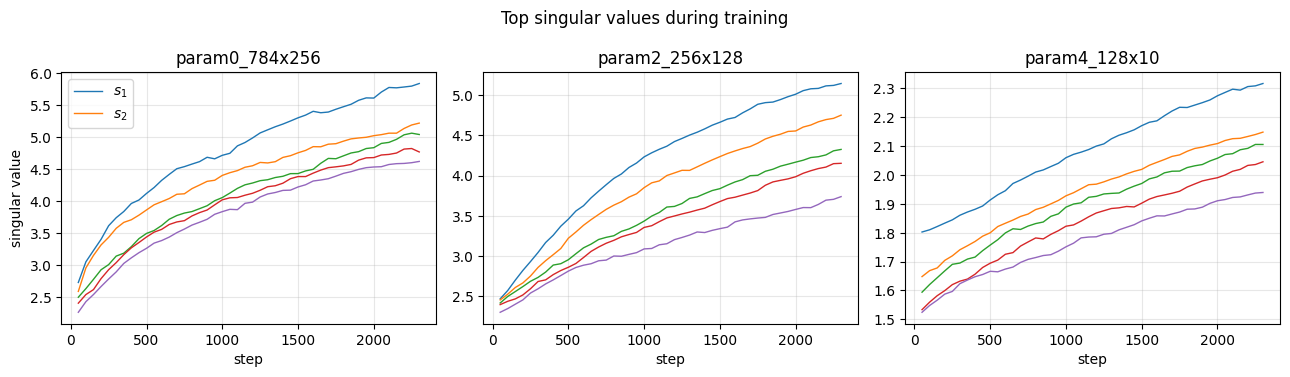

In [9]:
data = np.load("../runs/mlp_mnist_spectra.npz")

# Keys look like param0_784x256_step50. Group them by matrix name.
history = {}
for key in data.files:
    name, step_part = key.rsplit("_step", 1)
    history.setdefault(name, []).append((int(step_part), data[key]))
for name in history:
    history[name].sort()

fig, axes = plt.subplots(1, len(history), figsize=(13, 3.8), sharex=True)
for ax, (name, snaps) in zip(axes, sorted(history.items()), strict=False):
    steps = [s for s, _ in snaps]
    top5 = np.array([sv[:5] for _, sv in snaps])
    for i in range(5):
        ax.plot(steps, top5[:, i], lw=1.0, label=f"$s_{i + 1}$" if i < 2 else None)
    ax.set_title(name)
    ax.set_xlabel("step")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("singular value")
axes[0].legend()
plt.suptitle("Top singular values during training")
plt.tight_layout()
plt.show()

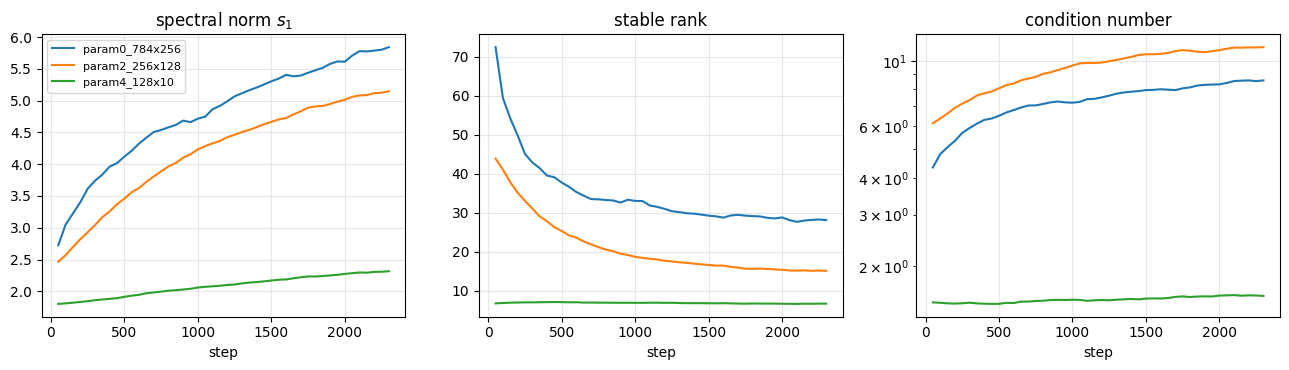

In [10]:
def stable_rank(sv):
    return float((sv**2).sum() / sv[0] ** 2)


def condition_number(sv):
    return float(sv[0] / sv[-1]) if sv[-1] > 0 else float("inf")


fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for name, snaps in sorted(history.items()):
    steps = [s for s, _ in snaps]
    axes[0].plot(steps, [sv[0] for _, sv in snaps], label=name)
    axes[1].plot(steps, [stable_rank(sv) for _, sv in snaps], label=name)
    axes[2].plot(steps, [condition_number(sv) for _, sv in snaps], label=name)
for ax, title in zip(
    axes, ["spectral norm $s_1$", "stable rank", "condition number"], strict=False
):
    ax.set_xlabel("step")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[2].set_yscale("log")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 6.2 Reading the plots

Three phenomena appear in this run, and they form the empirical basis for
the project's continuing research question.

**Dominant directions grow.** The largest singular values of every layer
rise steadily from their Marchenko-Pastur starting bulk, most sharply in the
first epoch while the loss falls fastest. Gradient descent is not moving the
weight matrices isotropically - it is pumping energy into a small number of
directions that matter for the task.

**Stable rank falls.** Since the Frobenius norm grows more slowly than the
spectral norm, the stable rank $\lVert W\rVert_F^2 / s_1^2$ *decreases* -
the layers concentrate. The effect is strongest in the final 128x10 layer,
whose job is to collapse features onto 10 class directions, and mildest in
the first layer, which must preserve enough of the input to feed everything
above it.

**Conditioning deteriorates, moderately.** The gap between the growing head
of the spectrum and the roughly static tail widens the condition number over
training - the anisotropy the network learns is exactly what a fresh random
matrix does not have.

A caveat belongs here. These are observations from one architecture, one
dataset, one optimizer, and one seed. They motivate rather than establish
the follow-up questions - whether the final spectrum can be *targeted at
initialization* (a spectrum-aware initialization scheme, the planned
original contribution of this project's next phase), and how the picture
changes for attention layers. Both are tracked on the repository road map.

## 7. Conclusion

The framework works - a NumPy-only stack whose autograd engine survives
finite-difference checking on every operation, whose optimizers reproduce
their textbook behavior on quadratics, and whose MLP reaches ~98% test
accuracy on MNIST. Every formula the code relies on was derived above from
the chain rule and elementary probability. And instrumenting training with
the SVD turned the abstract statement "the network learns structure" into
measurable, reproducible spectral signatures.

## References

- Glorot, X. & Bengio, Y. (2010). Understanding the difficulty of training
  deep feedforward neural networks. AISTATS.
- He, K., Zhang, X., Ren, S. & Sun, J. (2015). Delving deep into rectifiers.
  ICCV.
- Kingma, D. P. & Ba, J. (2015). Adam, a method for stochastic
  optimization. ICLR.
- Roy, O. & Vetterli, M. (2007). The effective rank, a measure of effective
  dimensionality. EUSIPCO.
- Marchenko, V. A. & Pastur, L. A. (1967). Distribution of eigenvalues for
  some sets of random matrices. Mat. Sb.
- LeCun, Y., Cortes, C. & Burges, C. The MNIST database of handwritten
  digits.